# Machine Learning Models - Hotspot

In [121]:
#Libraries needed: 

#Data Manipulation:
import pandas as pd
import numpy as np

#Visualization: 
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve

#Supervised Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold, 
    GridSearchCV,
    ParameterGrid
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error, 
    mean_squared_error
)

In [125]:
# modeling dataset for mutation hotspot prediction
model_df = pd.read_csv('finalseq_df.csv')

model_df.head(3)

,hotspot,mutation_rate,wuhan_resnum,rsa,asa,q8,p[q8_G],p[q8_H],p[q8_I],p[q8_B],...,positive,special,charge_ref,charge_win9,charge_win15,charge_win21,gp_ref,gp_win9,gp_win15,gp_win21
0,1,0.04,1.0,0.660813,148.022039,C,0.000175,0.000576,0.000018,0.000184,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.090909
1,1,0.04,2.0,0.682652,163.836508,C,0.000101,0.000402,0.000006,0.000074,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,0.083333
2,1,0.06,3.0,0.672084,116.942663,C,0.000074,0.000361,0.000003,0.000033,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.100000,0.076923


In [89]:
#rename the columns to exclude the []
model_df = model_df.rename(columns={
    "p[q8_G]": "p_q8_G",
    "p[q8_H]": "p_q8_H",
    "p[q8_I]": "p_q8_I",
    "p[q8_B]": "p_q8_B",
    "p[q8_E]": "p_q8_E",
    "p[q8_S]": "p_q8_S",
    "p[q8_T]": "p_q8_T",
    "p[q8_C]": "p_q8_C"
})

## Random Split

In [19]:
#model_df.columns

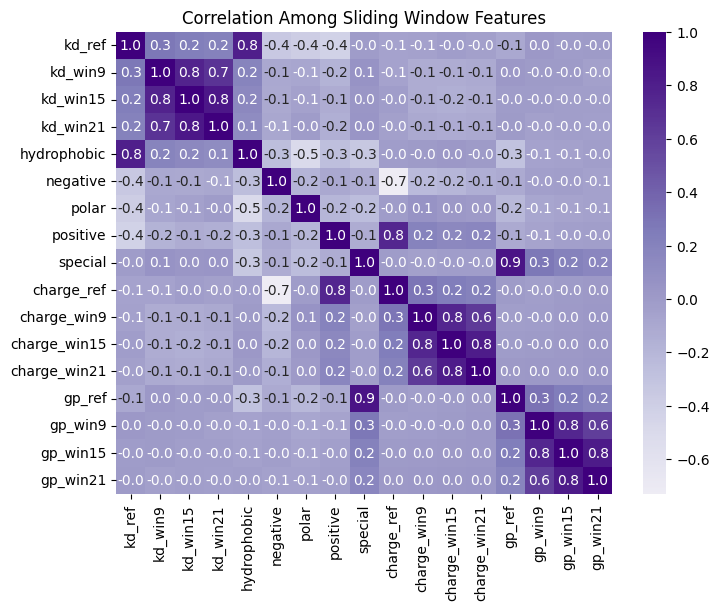

In [17]:
#check correlation between features

window_features = [
    'kd_ref', 'kd_win9', 'kd_win15','kd_win21', 
    'hydrophobic', 'negative', 'polar', 'positive','special',
    'charge_ref', 'charge_win9', 'charge_win15', 'charge_win21',
    'gp_ref', 'gp_win9', 'gp_win15', 'gp_win21'
]

corr = model_df[window_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Purples",
    center=0,
    fmt=".1f"
)

plt.title("Correlation Among Sliding Window Features")
plt.show()


In [18]:
#class imbalance

model_df['hotspot'].value_counts()

hotspot
0    1144
1     129
Name: count, dtype: int64

### Logistic Regression-baseline model

In [90]:
features = [
    'rsa', 'asa', 
    'p_q8_G', 'p_q8_H', 'p_q8_I', 'p_q8_B', 'p_q8_E', 'p_q8_S','p_q8_T', 'p_q8_C', 'disorder', 
    'kd_ref', 'kd_win9', 'kd_win15','kd_win21', 
    'hydrophobic', 'negative', 'polar', 'positive','special', 
    'charge_ref', 'charge_win9', 'charge_win15', 'charge_win21',
    'gp_ref', 'gp_win9', 'gp_win15', 'gp_win21'
]


#split the data into train and validation sets

X = model_df[features]
y = model_df['hotspot']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

# scale the features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Baseline: logistic Regression (Full Model)

lr_model_1 = LogisticRegression(
    class_weight = "balanced",
    max_iter = 5000,
    random_state = 42
)

lr_model_1.fit(
    X_train_scaled,
    y_train
)

# predictions
y_pred = lr_model_1.predict(X_test_scaled)
y_prob = lr_model_1.predict_proba(X_test_scaled)[:, 1]

# evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))



[[143  86]
 [ 14  12]]
              precision    recall  f1-score   support

           0       0.91      0.62      0.74       229
           1       0.12      0.46      0.19        26

    accuracy                           0.61       255
   macro avg       0.52      0.54      0.47       255
weighted avg       0.83      0.61      0.69       255

ROC-AUC: 0.5473631172321128
PR-AUC: 0.11671826190698929


In [91]:
# Logistic Regression (Reduced)

features_red = [
    'rsa', 'asa', 
    'p_q8_G', 'p_q8_H', 'p_q8_I', 'p_q8_B', 'p_q8_E', 'p_q8_S','p_q8_T', 'p_q8_C', 'disorder',  
    'hydrophobic', 'negative', 'polar', 'positive','special', 
    'kd_win9', 'charge_win9', 'gp_win9',
]


#split the data into train and validation sets

X_red = model_df[features_red]
y_red = model_df['hotspot']

X_train,X_test,y_train,y_test = train_test_split(
    X_red,
    y_red,
    test_size = 0.2,
    stratify = y_red,
    random_state = 42
)

# scale the features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Baseline: logistic Regression (Full Model)

lr_model_2 = LogisticRegression(
    class_weight = "balanced",
    max_iter = 5000,
    random_state = 42
)

lr_model_2.fit(
    X_train_scaled,
    y_train
)

# predictions
y_pred_red = lr_model_2.predict(X_test_scaled)
y_prob_red = lr_model_2.predict_proba(X_test_scaled)[:, 1]

# evaluation
print(confusion_matrix(y_test, y_pred_red))
print(classification_report(y_test, y_pred_red))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_red))
print("PR-AUC:", average_precision_score(y_test, y_prob_red))

[[144  85]
 [ 12  14]]
              precision    recall  f1-score   support

           0       0.92      0.63      0.75       229
           1       0.14      0.54      0.22        26

    accuracy                           0.62       255
   macro avg       0.53      0.58      0.49       255
weighted avg       0.84      0.62      0.69       255

ROC-AUC: 0.5752435337588175
PR-AUC: 0.1318017129219405


In [39]:
comparison_df_lr = pd.DataFrame({
    "actual": y_test,
    
    "full_pred": y_pred,
    "red_pred": y_pred_red,
    
    "full_prob": y_prob,
    "red_prob": y_prob_red
})

comparison_df_lr = comparison_df_lr.sort_values(
    "red_prob",
    ascending=False
)

comparison_df_lr.head(20)

,actual,full_pred,red_pred,full_prob,red_prob
683,0,1,1,0.905408,0.891569
810,0,1,1,0.835745,0.880774
1157,0,1,1,0.812070,0.822300
10,1,1,1,0.804894,0.818842
1265,0,1,1,0.856327,0.813859
811,0,1,1,0.815806,0.810960
1258,0,1,1,0.748587,0.770840
1210,0,1,1,0.749388,0.758071
356,0,1,1,0.709760,0.740441
1244,0,1,1,0.791553,0.733152


### Elastic Net

In [92]:
#build elastic net model

enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty = "elasticnet",
        solver = "saga",
        class_weight = "balanced",
        max_iter = 10000,
        random_state = 42
    ))
    
])

param_grid = {
    "model__l1_ratio": [0.1,0.25,0.5,0.75,0.9],
    "model__C": [0.01,0.1,1,10]
}

enet_grid = GridSearchCV(
    enet_pipe,
    param_grid = param_grid,
    scoring = "average_precision", #pr-auc good for imbalance
    cv = 5,
    n_jobs = -1
)

enet_grid.fit(X_train,y_train)

print("Best parameters:", enet_grid.best_params_)
print("Best CV PR-AUC:", enet_grid.best_score_)

#evaluation
best_enet = enet_grid.best_estimator_


y_pred_enet = best_enet.predict(X_test)
y_prob_enet = best_enet.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_enet))
print(classification_report(y_test, y_pred_enet))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_enet))
print("PR-AUC:", average_precision_score(y_test, y_prob_enet))

Best parameters: {'model__C': 0.01, 'model__l1_ratio': 0.5}
Best CV PR-AUC: 0.2016003383232358
[[144  85]
 [ 15  11]]
              precision    recall  f1-score   support

           0       0.91      0.63      0.74       229
           1       0.11      0.42      0.18        26

    accuracy                           0.61       255
   macro avg       0.51      0.53      0.46       255
weighted avg       0.83      0.61      0.68       255

ROC-AUC: 0.5347665435001681
PR-AUC: 0.11667289423112734


C:\Users\bphul\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [47]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": enet_grid.best_estimator_
                 .named_steps["model"]
                 .coef_[0]
})

coef_df.sort_values("coef")

,feature,coef
3,p[q8_H],-0.058735
0,rsa,0.000000
2,p[q8_G],0.000000
4,p[q8_I],0.000000
6,p[q8_E],0.000000
5,p[q8_B],0.000000
7,p[q8_S],0.000000
8,p[q8_T],0.000000
14,kd_win21,0.000000
11,kd_ref,0.000000


### Random Forest

In [55]:
# Random Forest, expected to do the best considering it can capture the nonlinearity of biological systems and interactions between features

rf_model = RandomForestClassifier(
    n_estimators = 500,
    class_weight = "balanced",
    random_state = 42
)

rf_model.fit(X_train,y_train)

# evaluation
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

[[229   0]
 [ 24   2]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       229
           1       1.00      0.08      0.14        26

    accuracy                           0.91       255
   macro avg       0.95      0.54      0.55       255
weighted avg       0.91      0.91      0.87       255

ROC-AUC: 0.6242861941551898
PR-AUC: 0.24875389981241808


In [56]:
pd.Series(y_prob_rf).describe() #low hotspot probabilities 

count    255.000000
mean       0.101224
std        0.087402
min        0.004000
25%        0.048000
50%        0.080000
75%        0.128000
max        0.726000
dtype: float64

In [64]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

for t in [0.05, 0.10, 0.15, 0.20, 0.25]:
    pred_rf = (y_prob_rf >= t).astype(int)

    print("t:",t)
    print(confusion_matrix(y_test, pred_rf))
    print(classification_report(y_test, pred_rf))
   
    

ROC-AUC: 0.6242861941551898
PR-AUC: 0.24875389981241808
t: 0.05
[[ 61 168]
 [  4  22]]
              precision    recall  f1-score   support

           0       0.94      0.27      0.41       229
           1       0.12      0.85      0.20        26

    accuracy                           0.33       255
   macro avg       0.53      0.56      0.31       255
weighted avg       0.85      0.33      0.39       255

t: 0.1
[[147  82]
 [ 12  14]]
              precision    recall  f1-score   support

           0       0.92      0.64      0.76       229
           1       0.15      0.54      0.23        26

    accuracy                           0.63       255
   macro avg       0.54      0.59      0.49       255
weighted avg       0.85      0.63      0.70       255

t: 0.15
[[190  39]
 [ 18   8]]
              precision    recall  f1-score   support

           0       0.91      0.83      0.87       229
           1       0.17      0.31      0.22        26

    accuracy                      

In [82]:
comparison_df = pd.DataFrame({
    "actual": y_test,
    
    "full_pred": y_pred,
    "red_pred": y_pred_red,
    "enet_pred": y_pred_enet,
    "rf_pred":  y_pred_rf,
    
    "full_prob": y_prob,
    "red_prob": y_prob_red,
    "enet_prob": y_prob_enet,
    "rf_prob": y_prob_rf
})

comparison_df = comparison_df.sort_values(
    "full_prob",
    ascending=False
)

comparison_df.head(20)

,actual,full_pred,red_pred,enet_pred,rf_pred,full_prob,red_prob,enet_prob,rf_prob
683,0,1,1,1,0,0.905408,0.891569,0.599508,0.138
1265,0,1,1,1,0,0.856327,0.813859,0.598491,0.246
810,0,1,1,1,0,0.835745,0.880774,0.574441,0.262
811,0,1,1,1,0,0.815806,0.810960,0.581544,0.288
1157,0,1,1,1,0,0.812070,0.822300,0.530811,0.130
10,1,1,1,1,1,0.804894,0.818842,0.591036,0.726
1244,0,1,1,1,0,0.791553,0.733152,0.594871,0.044
1251,0,1,1,1,0,0.791153,0.700638,0.592734,0.052
1256,0,1,1,1,0,0.786933,0.712116,0.565078,0.070
814,0,1,1,1,0,0.752102,0.729825,0.568760,0.184


In [84]:
rf_results[
    rf_results["actual"] == 1
].sort_values(
    "rf_prob",
    ascending=False
)

,actual,rf_prob
10,1,0.726
0,1,0.706
182,1,0.290
30,1,0.274
221,1,0.246
252,1,0.226
197,1,0.176
210,1,0.170
953,1,0.132
455,1,0.130


### XGBoost

In [105]:
# XGBoost

scale_pos_weight = [25, 50, 100, 200]
 
xgb_model = XGBClassifier(
    objective = "binary:logistic",
    eval_metric = "logloss",
    random_state = 42
)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]

}

xgb_grid = GridSearchCV(
    estimator = xgb_model,
    param_grid = param_grid,
    scoring = "average_precision", #PR-AUC
    cv = 5,
    n_jobs = -1
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV PR-AUC:", xgb_grid.best_score_)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV PR-AUC: 0.267653345307134


In [107]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))

[[228   1]
 [ 25   1]]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       229
           1       0.50      0.04      0.07        26

    accuracy                           0.90       255
   macro avg       0.70      0.52      0.51       255
weighted avg       0.86      0.90      0.86       255

ROC-AUC: 0.6029559959690964
PR-AUC: 0.1990476703605949


In [106]:
comparison_df = pd.DataFrame({
    "actual": y_test,
    
    "full_pred": y_pred,
    "red_pred": y_pred_red,
    "enet_pred": y_pred_enet,
    "rf_pred":  y_pred_rf,
    "xgb_pred":  y_pred_xgb,
    
    "full_prob": y_prob,
    "red_prob": y_prob_red,
    "enet_prob": y_prob_enet,
    "rf_prob": y_prob_rf,
    "xgb_prob": y_prob_xgb,
})

comparison_df = comparison_df.sort_values(
    "full_prob",
    ascending=False
)

comparison_df.head(20)

,actual,full_pred,red_pred,enet_pred,rf_pred,xgb_pred,full_prob,red_prob,enet_prob,rf_prob,xgb_prob
683,0,1,1,1,0,0,0.905408,0.891569,0.599507,0.138,0.059644
1265,0,1,1,1,0,0,0.856327,0.813859,0.598492,0.246,0.382700
810,0,1,1,1,0,1,0.835745,0.880774,0.574441,0.262,0.548542
811,0,1,1,1,0,0,0.815806,0.810960,0.581544,0.288,0.243704
1157,0,1,1,1,0,0,0.812070,0.822300,0.530811,0.130,0.136342
10,1,1,1,1,1,0,0.804894,0.818842,0.591037,0.726,0.450788
1244,0,1,1,1,0,0,0.791553,0.733152,0.594872,0.044,0.057574
1251,0,1,1,1,0,0,0.791153,0.700638,0.592735,0.052,0.041041
1256,0,1,1,1,0,0,0.786933,0.712116,0.565079,0.070,0.090901
814,0,1,1,1,0,0,0.752102,0.729825,0.568760,0.184,0.133562


In [98]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))

for t in [0.05, 0.10, 0.15, 0.20, 0.25]:
    pred_xgb = (y_prob_xgb >= t).astype(int)

    print("t:",t)
    print(confusion_matrix(y_test, pred_xgb))
    print(classification_report(y_test, pred_xgb))

ROC-AUC: 0.6029559959690964
PR-AUC: 0.1990476703605949
t: 0.05
[[ 88 141]
 [  5  21]]
              precision    recall  f1-score   support

           0       0.95      0.38      0.55       229
           1       0.13      0.81      0.22        26

    accuracy                           0.43       255
   macro avg       0.54      0.60      0.38       255
weighted avg       0.86      0.43      0.51       255

t: 0.1
[[163  66]
 [ 14  12]]
              precision    recall  f1-score   support

           0       0.92      0.71      0.80       229
           1       0.15      0.46      0.23        26

    accuracy                           0.69       255
   macro avg       0.54      0.59      0.52       255
weighted avg       0.84      0.69      0.74       255

t: 0.15
[[194  35]
 [ 19   7]]
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       229
           1       0.17      0.27      0.21        26

    accuracy                       

In [104]:
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance",
              ascending = False)

xgb_importance.head(15)

,feature,importance
9,p_q8_C,0.108047
18,gp_win9,0.086416
2,p_q8_G,0.075421
11,hydrophobic,0.064254
3,p_q8_H,0.062521
10,disorder,0.061615
5,p_q8_B,0.057998
4,p_q8_I,0.057583
0,rsa,0.055818
16,kd_win9,0.054781


### Evaluation 

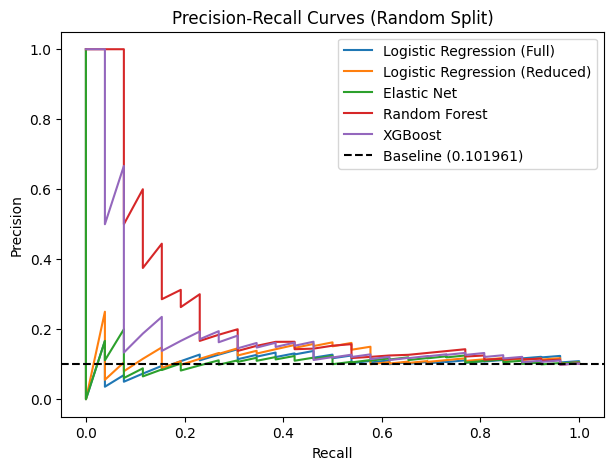

In [128]:
# Evaluation Curve

plt.figure(figsize = (7,5))

models = {
    "Logistic Regression (Full)": y_prob,
    "Logistic Regression (Reduced)": y_prob_red,
    "Elastic Net": y_prob_enet,
    "Random Forest":y_prob_rf,
    "XGBoost": y_prob_xgb
}

for name, probs in models.items():

    precision,recall,_ = precision_recall_curve(
        y_test,
        probs
    )

    plt.plot(
        recall,
        precision,
        label = name
    )
    
baseline = y_test.mean()

plt.axhline(
    baseline,
    linestyle = "--",
    color = "black",
    label = f"Baseline ({baseline:2f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Random Split)")
plt.legend()

plt.show()

In [144]:
# results for comparison table

# Logistic Regression (full)
roc_lr = roc_auc_score(y_test,y_prob)
pr_lr = average_precision_score(y_test, y_prob)
f1_lr = f1_score(y_test,y_pred)

# Logistic Regression (Reduced)
roc_lr_red = roc_auc_score(y_test,y_prob_red)
pr_lr_red = average_precision_score(y_test, y_prob_red)
f1_lr_red = f1_score(y_test,y_pred_red)

# Elastic Net
roc_enet = roc_auc_score(y_test,y_prob_enet)
pr_enet = average_precision_score(y_test, y_prob_enet)
f1_enet = f1_score(y_test,y_pred_enet)

# Random Forest
roc_rf = roc_auc_score(y_test,y_prob_rf)
pr_rf = average_precision_score(y_test, y_prob_rf)
f1_rf = f1_score(y_test,y_pred_rf)

#XGBoost
roc_xgb = roc_auc_score(y_test,y_prob_xgb)
pr_xgb = average_precision_score(y_test, y_prob_xgb)
f1_xgb = f1_score(y_test,y_pred_xgb)

In [148]:
# Evaluation Table 
results = {
    "Model": [
        "Logistic Regression",
        "Reduced Logistic Regression",
        "Elastic Net",
        "Random Forest",
        "XGBoost",
    ],
    "ROC-AUC": [
        roc_lr,
        roc_lr_red,
        roc_enet,
        roc_rf,
        roc_xgb,
        
    ],
    "PR-AUC": [
        pr_lr,
        pr_lr_red,
        pr_enet,
        pr_rf,
        pr_xgb,
       
    ],
    "F1": [
        f1_lr,
        f1_lr_red,
        f1_enet,
        f1_rf,
        f1_xgb,
        
    ]
}

results_df = pd.DataFrame(results).sort_values(
    "PR-AUC",
    ascending = False
)

results_df.round(3)

,Model,ROC-AUC,PR-AUC,F1
3,Random Forest,0.624,0.249,0.143
4,XGBoost,0.603,0.199,0.071
1,Reduced Logistic Regression,0.575,0.132,0.224
0,Logistic Regression,0.547,0.117,0.194
2,Elastic Net,0.535,0.117,0.180


## Regional Split

In [108]:
#regions with higher mutation rates

model_df_regional = model_df[~model_df['wuhan_resnum'].between(400,600)].copy()
test_df_regional = model_df[model_df['wuhan_resnum'].between(400,600)].copy()

X_train_reg = model_df_regional[features]
y_train_reg = model_df_regional['hotspot']

X_test_reg = test_df_regional[features]
y_test_reg = test_df_regional['hotspot']

### Random Forest

In [109]:
#random forest for regional split

rf_model_reg = RandomForestClassifier(
    n_estimators = 500,
    class_weight = "balanced",
    random_state = 42
)

rf_model_reg.fit(X_train_reg,y_train_reg)

# evaluation
y_pred_rf_reg = rf_model_reg.predict(X_test_reg)
y_prob_rf_reg = rf_model_reg.predict_proba(X_test_reg)[:,1]

print(confusion_matrix(y_test_reg, y_pred_rf_reg))
print(classification_report(y_test_reg, y_pred_rf_reg))
print("ROC-AUC:", roc_auc_score(y_test_reg, y_prob_rf_reg))
print("PR-AUC:", average_precision_score(y_test_reg, y_prob_rf_reg))

[[169   1]
 [ 31   0]]
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       170
           1       0.00      0.00      0.00        31

    accuracy                           0.84       201
   macro avg       0.42      0.50      0.46       201
weighted avg       0.71      0.84      0.77       201

ROC-AUC: 0.5304554079696395
PR-AUC: 0.16798976779929026


In [113]:
print("ROC-AUC:", roc_auc_score(y_test_reg, y_prob_rf_reg))
print("PR-AUC:", average_precision_score(y_test_reg, y_prob_rf_reg))

for t in [0.05, 0.10, 0.15, 0.20, 0.25]:
    pred_rf_reg = (y_prob_rf_reg >= t).astype(int)

    print("t:",t)
    print(confusion_matrix(y_test_reg, pred_rf_reg))
    print(classification_report(y_test_reg, pred_rf_reg))
   

ROC-AUC: 0.5304554079696395
PR-AUC: 0.16798976779929026
t: 0.05
[[ 42 128]
 [  5  26]]
              precision    recall  f1-score   support

           0       0.89      0.25      0.39       170
           1       0.17      0.84      0.28        31

    accuracy                           0.34       201
   macro avg       0.53      0.54      0.33       201
weighted avg       0.78      0.34      0.37       201

t: 0.1
[[90 80]
 [16 15]]
              precision    recall  f1-score   support

           0       0.85      0.53      0.65       170
           1       0.16      0.48      0.24        31

    accuracy                           0.52       201
   macro avg       0.50      0.51      0.45       201
weighted avg       0.74      0.52      0.59       201

t: 0.15
[[121  49]
 [ 20  11]]
              precision    recall  f1-score   support

           0       0.86      0.71      0.78       170
           1       0.18      0.35      0.24        31

    accuracy                          

In [115]:
pd.DataFrame({
    "actual": y_test_reg,
    "prob": y_prob_rf_reg,
}).groupby("actual")["prob"].describe()

,count,mean,std,min,25%,50%,75%,max
actual,,,,,,,,
0,170.0,0.117741,0.089057,0.014,0.0505,0.088,0.1615,0.508
1,31.0,0.121548,0.080352,0.030,0.0570,0.082,0.1720,0.314


### XGBoost

In [116]:
# XGBoost for regional split

scale_pos_weight = [25, 50, 100, 200]
 
xgb_model_regional = XGBClassifier(
    objective = "binary:logistic",
    eval_metric = "logloss",
    random_state = 42
)

param_grid_reg = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]

}

xgb_grid_reg = GridSearchCV(
    estimator = xgb_model_regional,
    param_grid = param_grid_reg,
    scoring = "average_precision", #PR-AUC
    cv = 5,
    n_jobs = -1
)

xgb_grid_reg.fit(X_train_reg, y_train_reg)

print("Best parameters:", xgb_grid_reg.best_params_)
print("Best CV PR-AUC:", xgb_grid_reg.best_score_)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV PR-AUC: 0.08882482248430831


In [154]:
best_xgb_reg = xgb_grid_reg.best_estimator_

y_pred_xgb_reg = best_xgb_reg.predict(X_test_reg)
y_prob_xgb_reg = best_xgb_reg.predict_proba(X_test_reg)[:, 1]

print(confusion_matrix(y_test_reg, y_pred_xgb_reg))
print(classification_report(y_test_reg, y_pred_xgb_reg))
print("ROC-AUC:", roc_auc_score(y_test_reg, y_prob_xgb_reg))
print("PR-AUC:", average_precision_score(y_test_reg, y_prob_xgb_reg))

[[170   0]
 [ 31   0]]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       170
           1       0.00      0.00      0.00        31

    accuracy                           0.85       201
   macro avg       0.42      0.50      0.46       201
weighted avg       0.72      0.85      0.78       201

ROC-AUC: 0.5441176470588235
PR-AUC: 0.1917635424436852


C:\Users\bphul\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bphul\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bphul\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [120]:
comparison_df_reg = pd.DataFrame({
    "actual": y_test_reg,
    
    "rf_pred":  y_pred_rf_reg,
    "xgb_pred":  y_pred_xgb_reg,
    
    "rf_prob": y_prob_rf_reg,
    "xgb_prob": y_prob_xgb_reg,
})

comparison_df_reg = comparison_df_reg.sort_values(
    "rf_prob",
    ascending=False
)

comparison_df_reg.head(20)

,actual,rf_pred,xgb_pred,rf_prob,xgb_prob
441,0,1,0,0.508,0.181872
529,0,0,0,0.470,0.211971
463,0,0,0,0.376,0.273851
531,0,0,0,0.344,0.129692
462,0,0,0,0.326,0.204375
442,0,0,0,0.316,0.193949
532,0,0,0,0.316,0.193949
445,1,0,0,0.314,0.173629
447,0,0,0,0.312,0.121371
522,0,0,0,0.308,0.086862


### Evaluation (Regional Split)

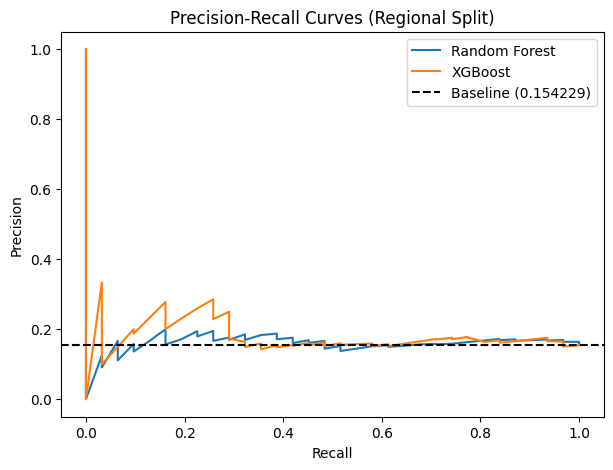

In [132]:
#  Evaluation Curve

plt.figure(figsize = (7,5))

models_reg = {
    "Random Forest":y_prob_rf_reg,
    "XGBoost": y_prob_xgb_reg
}

for name, probs in models_reg.items():

    precision,recall,_ = precision_recall_curve(
        y_test_reg,
        probs
    )

    plt.plot(
        recall,
        precision,
        label = name
    )
    
baseline = y_test_reg.mean()

plt.axhline(
    baseline,
    linestyle = "--",
    color = "black",
    label = f"Baseline ({baseline:2f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Regional Split)")
plt.legend()

plt.show()

In [151]:
# results for comparison table

# Random Forest
roc_rf_reg = roc_auc_score(y_test_reg,y_prob_rf_reg)
pr_rf_reg = average_precision_score(y_test_reg, y_prob_rf_reg)
f1_rf_reg = f1_score(y_test_reg,y_pred_rf_reg)

#XGBoost
roc_xgb_reg = roc_auc_score(y_test_reg,y_prob_xgb_reg)
pr_xgb_reg = average_precision_score(y_test_reg, y_prob_xgb_reg)
f1_xgb_reg = f1_score(y_test_reg,y_pred_xgb_reg)

In [153]:
# Evaluation Table 
results_reg = {
    "Model": [
        "Random Forest",
        "XGBoost",
    ],
    "ROC-AUC": [
        roc_rf_reg,
        roc_xgb_reg,
        
    ],
    "PR-AUC": [
        pr_rf_reg,
        pr_xgb_reg,
       
    ],
    "F1": [
        f1_rf_reg,
        f1_xgb_reg,
        
    ]
}

results_reg_df = pd.DataFrame(results_reg).sort_values(
    "PR-AUC",
    ascending = False
)

results_reg_df.round(3)

,Model,ROC-AUC,PR-AUC,F1
1,XGBoost,0.544,0.192,0.0
0,Random Forest,0.530,0.168,0.0
